# GA4 E-Commerce Funnel Analyse

**Dataset:** `bigquery-public-data.ga4_obfuscated_sample_ecommerce`  
**Ziel:** Den Kaufprozess von der ersten Interaktion bis zum Kauf verstehen und Optimierungspotenziale identifizieren.

---

## Struktur des Notebooks


1. Setup & Analysezeitraum
2. Überblick und Datenqualitätscheck
3. Event Inventory ## Was passiert überhaupt?
4. Standard E-Commerce Funnel (Event-Level)
5. User-Level Funnel ## Wie viele User schließen jeden Schritt ab?
6. Drop-off Analyse ## Wo werden die meisten User verloren?
7. Segmentierung ## Gibt es unterschiede bei den Geräten?
8. Revenue-Analyse
9. Visualisierungen
10. Zusammenfassung


## 1. Setup

In [4]:
#%pip install --upgrade bigframes matplotlib
import bigframes.pandas as bpd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import pandas as pd

PROJECT_ID = "funnel-analysis-demo-491115"
LOCATION = "eu"

DATE_START = '20210101'
DATE_END   = '20210131'

pd.set_option('display.max_rows', 20)

def run_query(query):
    return bpd.read_gbq(query)

Analysis_period = {"start": DATE_START, "end": DATE_END}

## 2. Überblick und Datenqualitätscheck

Überblick über den Datensatz und ein paar Qualitätschecks

In [79]:
run_query(f"""
SELECT
  COUNT(*)                        AS total_events,
  COUNT(DISTINCT user_pseudo_id)  AS unique_users,
  COUNT(DISTINCT event_date)      AS days_in_dataset,
  MIN(event_date)                 AS first_day,
  MAX(event_date)                 AS last_day
FROM `bigquery-public-data.ga4_obfuscated_sample_ecommerce.events_*`
WHERE _TABLE_SUFFIX BETWEEN '{DATE_START}' AND '{DATE_END}'
""")


,total_events,unique_users,days_in_dataset,first_day,last_day
0,1210147,94790,31,20210101,20210131


Gibt es Tage an dem keine Events stattgefunden haben?

In [ ]:
df_date_check = bpd.read_gbq(f"""
SELECT
  PARSE_DATE('%Y%m%d', event_date) AS date,
  COUNT(*) AS events
FROM `bigquery-public-data.ga4_obfuscated_sample_ecommerce.events_*`
WHERE _TABLE_SUFFIX BETWEEN '{DATE_START}' AND '{DATE_END}'
GROUP BY date
""")

df_date_check = df_date_check.to_pandas().sort_values('date')

df_date_check

,date,events
18,2021-01-01,22096
2,2021-01-02,23599
19,2021-01-03,24743
10,2021-01-04,31395
11,2021-01-05,42827
...,...,...
20,2021-01-27,48665
4,2021-01-28,43131
13,2021-01-29,40877
22,2021-01-30,30395


Gibt es fehlende SessionIDs? --> Nein, es gibt keine fehlende SessionIDs

In [2]:
df_session_check = bpd.read_gbq(f"""
SELECT
  COUNT(*) AS total_events,
  COUNTIF((
    SELECT ep.value.int_value
    FROM UNNEST(event_params) ep
    WHERE ep.key = 'ga_session_id') IS NULL) AS missing_session_id,
  SAFE_DIVIDE(
    COUNTIF((
      SELECT ep.value.int_value
      FROM UNNEST(event_params) ep
      WHERE ep.key = 'ga_session_id'
    ) IS NULL),
    COUNT(*)
  ) AS missing_rate
FROM `bigquery-public-data.ga4_obfuscated_sample_ecommerce.events_*`
WHERE _TABLE_SUFFIX BETWEEN '{DATE_START}' AND '{DATE_END}'
""")

df_session_check

,total_events,missing_session_id,missing_rate
0,1210147,0,0.0


Gibt es Events in der falschen Reihenfolge? --> Keine ungewöglichen Eventabfolgen

In [69]:
df_events_check = bpd.read_gbq(f"""
WITH ordered_events AS (
  SELECT
    user_pseudo_id,
    event_name,
    event_timestamp,
    LAG(event_name) OVER (
      PARTITION BY user_pseudo_id
      ORDER BY event_timestamp
    ) AS prev_event
  FROM `bigquery-public-data.ga4_obfuscated_sample_ecommerce.events_*`
  WHERE _TABLE_SUFFIX BETWEEN '{DATE_START}' AND '{DATE_END}'
)

SELECT
  event_name,
  prev_event,
  COUNT(*) AS occurrences
FROM ordered_events
WHERE prev_event IS NOT NULL
GROUP BY event_name, prev_event
""")

df_events_check = df_events_check.to_pandas().sort_values(['occurrences'], ascending=False)

df_events_check.head(20)

,event_name,prev_event,occurrences
82,page_view,user_engagement,135435
73,user_engagement,page_view,105103
138,scroll,page_view,82478
6,user_engagement,scroll,71486
147,page_view,session_start,68258
61,page_view,first_visit,51826
116,page_view,page_view,46346
49,view_promotion,page_view,43959
121,session_start,page_view,42096
64,page_view,scroll,38309


Gibt es fehlende Umsätze? --> Ja, gibt es und sogar relativ viel mit knapp 25%. Bei diesen hohen Prozenten muss man das nachverfolgen

In [70]:
df_revenue_check = bpd.read_gbq(f"""
SELECT
  COUNT(*) AS total_purchases,

  COUNTIF(
    COALESCE(
      (SELECT ep.value.double_value FROM UNNEST(event_params) ep WHERE ep.key = 'value'),
      (SELECT ep.value.int_value    FROM UNNEST(event_params) ep WHERE ep.key = 'value')
    ) IS NULL
  ) AS missing_value,

  SAFE_DIVIDE(
    COUNTIF(
      COALESCE(
        (SELECT ep.value.double_value FROM UNNEST(event_params) ep WHERE ep.key = 'value'),
        (SELECT ep.value.int_value    FROM UNNEST(event_params) ep WHERE ep.key = 'value')
      ) IS NULL
    ),
    COUNT(*)
  ) AS missing_rate

FROM `bigquery-public-data.ga4_obfuscated_sample_ecommerce.events_*`
WHERE event_name = 'purchase'
  AND _TABLE_SUFFIX BETWEEN '{DATE_START}' AND '{DATE_END}'
""")

df_revenue_check

,total_purchases,missing_value,missing_rate
0,1204,300,0.249169


Gibt es Einkäufe ohne Produkte? --> Obwohl bei 25% der Einkäufe der Umsatz fehlt, hat jeder Einkauf mindestens 1 Item. 

In [71]:
df_purchase_check = bpd.read_gbq(f"""
SELECT
  COUNT(*) AS total_purchases,
  COUNTIF(ARRAY_LENGTH(items) > 0) AS with_items,
  COUNTIF(ARRAY_LENGTH(items) = 0 OR items IS NULL) AS without_items
FROM `bigquery-public-data.ga4_obfuscated_sample_ecommerce.events_*`
WHERE event_name = 'purchase'
  AND _TABLE_SUFFIX BETWEEN '{DATE_START}' AND '{DATE_END}'
  """)
df_purchase_check

,total_purchases,with_items,without_items
0,1204,1204,0


Wie viele Purchase-Events haben zwar Items aber entweder keine Werte oder die Werte 0 bei Preis und Quantität? --> Es ist sehr interessant, das genau die 300 Purchase Events die für die 25% Missing Values verantworltich sind zwar Items haben aber sowohl den Wert NULL bei Preis und Quanität haben. Dieses Datenproblem kann unter verschiedenen Umständen in diesen Datensatz gelangt sein. Zum Beispiel dass das Event ausgelöst wurde bevor alle Daten verfügbar waren, Probleme beim Tracking oder das eben bewusst von Google fehlerhafte Daten mit reingebracht wurden.

In [73]:
df_item_check = bpd.read_gbq(f"""
SELECT
  COUNT(*) AS total,

  COUNTIF(item.price IS NULL) AS price_null,
  COUNTIF(item.quantity IS NULL) AS quantity_null,

  COUNTIF(item.price = 0) AS price_zero,
  COUNTIF(item.quantity = 0) AS quantity_zero

FROM `bigquery-public-data.ga4_obfuscated_sample_ecommerce.events_*`,
UNNEST(items) AS item

WHERE event_name = 'purchase'
  AND COALESCE(
    (SELECT ep.value.double_value FROM UNNEST(event_params) ep WHERE ep.key = 'value'),
    (SELECT ep.value.int_value FROM UNNEST(event_params) ep WHERE ep.key = 'value')
  ) IS NULL
  AND _TABLE_SUFFIX BETWEEN '{DATE_START}' AND '{DATE_END}'
  """)

df_item_check

,total,price_null,quantity_null,price_zero,quantity_zero
0,300,300,300,0,0


## 3. Event Inventory

Welche Events gibt es überhaupt?

In [4]:
df_events = bpd.read_gbq(f"""
SELECT
  event_name,
  COUNT(*)                        AS event_count,
  COUNT(DISTINCT user_pseudo_id)  AS unique_users,
  ROUND(COUNT(*) * 100.0 / SUM(COUNT(*)) OVER(), 2) AS percentage_of_all_events
FROM `bigquery-public-data.ga4_obfuscated_sample_ecommerce.events_*`
WHERE _TABLE_SUFFIX BETWEEN '{DATE_START}' AND '{DATE_END}'
GROUP BY event_name
""")


df_events = df_events.sort_values(by='event_count', ascending=False)
df_events.head(20).to_pandas()

,event_name,event_count,unique_users,percentage_of_all_events
8,page_view,419004,94630,34.62
6,user_engagement,250097,72574,20.67
5,scroll,138997,45594,11.49
11,session_start,116549,93552,9.63
1,first_visit,88873,88830,7.34
16,view_item,86971,19629,7.19
10,view_promotion,53885,32131,4.45
4,add_to_cart,15522,3832,1.28
0,begin_checkout,11034,1924,0.91
14,select_item,10229,4991,0.85


## 4. Funnel Analyse auf der Event-Ebene

In dieser Analyse wird geschaut, wie oft jedes Event aufgerufen wurde. Im gegensatz zu der User und Session Ebene wird hier nicht darauf geachtet, ob dieselben Nutzer oder Session die Schritte durchlaufen. Das heißt, ein User kann mehrmals ein Event ausführen und es muss in keiner bestimmten reihenfolge stattfinden.

Da der Event-Funnel keine echte Konvertierung misst, wird im nächsten Schritt ein User-basierter Funnel berechnet, um die tatsächliche Konvertierung zwischen den Schritten zu analysieren.

In [7]:
FUNNEL_STEPS = [
    'view_item',
    'add_to_cart',
    'begin_checkout',
    'add_shipping_info',
    'add_payment_info',
    'purchase'
]

df_funnel_events = bpd.read_gbq(f"""
    SELECT
      event_name,
      COUNT(*) AS events
    FROM `bigquery-public-data.ga4_obfuscated_sample_ecommerce.events_*`
    WHERE _TABLE_SUFFIX BETWEEN '{DATE_START}' AND '{DATE_END}'
      AND event_name IN (
        'view_item', 'add_to_cart',
        'begin_checkout', 'add_shipping_info',
        'add_payment_info', 'purchase'
      )
    GROUP BY event_name
""")

df_funnel_events = (
    df_funnel_events
    .to_pandas()
    .set_index('event_name')
    .reindex(FUNNEL_STEPS)
    .reset_index()
)

df_funnel_events

,event_name,events
0,view_item,86971
1,add_to_cart,15522
2,begin_checkout,11034
3,add_shipping_info,3952
4,add_payment_info,2841
5,purchase,1204


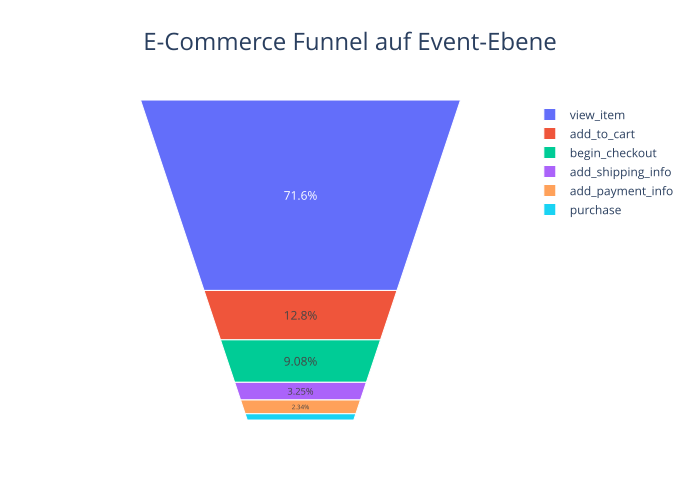

In [11]:
import plotly.express as px

label_map = {
    'view_item':         'Produkt angesehen',
    'add_to_cart':       'In den Warenkorb',
    'begin_checkout':    'Checkout gestartet',
    'add_shipping_info': 'Versand eingegeben',
    'add_payment_info':  'Zahlung eingegeben',
    'purchase':          'Kauf abgeschlossen',
}

df_funnel_plot = df_funnel_events.copy()
df_funnel_plot['step'] = df_funnel_plot['event_name'].map(label_map)

fig = px.funnel_area(
    df_funnel_plot,
    values='events',
    names='event_name',
    title='E-Commerce Funnel auf Event-Ebene')

fig.update_layout(title_x=0.5, title_font_size=24)

fig.write_image("../figures/funnel_events_overview.png", scale=2)
fig.show(renderer='svg')

In [46]:
df_funnel_events['events_rel'] = df_funnel_events['events'] / df_funnel_events['events'].iloc[0] * 100

df_funnel_events['label'] = df_funnel_events['events_rel'].round(2).astype(str) + "%"

fig = px.funnel(df_funnel_events, y=df_funnel_events['event_name'].map(label_map), x='events_rel', title='E-Commerce Funnel auf Event-Ebene')

fig.update_traces(
    text=df_funnel_events['events_rel'].map(lambda x: f"{x:.2f}%"),
    textinfo="text" 
    
)

fig.update_layout(
    xaxis_title='Anteil der Nutzer in %',
    yaxis_title='Funnel-Schritte',
    title_x=0.5,    
)

fig.show()


## 5. Funnel Analyse auf User-Ebene

Dieser Funnel wird auf User-Ebene berechnet, da auf Event-Eben nicht auf die User-Journey geachtet wird.
Dazu wird der frühste Timestamp pro Event-Typ bestimmt und ein User durchläuft den Funnel, insofern das Event exisitiert und die Events in der zeitlich richtigen Reihenfolge sind.

Die einzige Einschränkung dabei ist dass das ganze auf den Analysezeitraum geachtet wird und nicht per Session. Diese folgt danach
Es ist jedoch trotzdem interessant das ein Kunde sich z.B am Montag ein Produkt anschaut, am Mittwoch es in den Warenkorb legt und am Samstag dann kauft. 

Daraus lassen sich Schlüsse zur genrellen Conversion-Fähigkeit der User ziehen.

In [28]:
df_ordered_funnel = bpd.read_gbq(f"""
WITH user_steps AS (
  SELECT
    user_pseudo_id,
    MIN(IF(event_name = 'view_item',         event_timestamp, NULL)) AS ts_view_item,
    MIN(IF(event_name = 'add_to_cart',       event_timestamp, NULL)) AS ts_add_to_cart,
    MIN(IF(event_name = 'begin_checkout',    event_timestamp, NULL)) AS ts_begin_checkout,
    MIN(IF(event_name = 'add_shipping_info', event_timestamp, NULL)) AS ts_add_shipping_info,
    MIN(IF(event_name = 'add_payment_info',  event_timestamp, NULL)) AS ts_add_payment_info,
    MIN(IF(event_name = 'purchase',          event_timestamp, NULL)) AS ts_purchase
  FROM `bigquery-public-data.ga4_obfuscated_sample_ecommerce.events_*`
  WHERE _TABLE_SUFFIX BETWEEN '{DATE_START}' AND '{DATE_END}'
  GROUP BY user_pseudo_id
)
SELECT
  COUNTIF(ts_view_item IS NOT NULL)                                                                       AS view_item,
  COUNTIF(ts_view_item IS NOT NULL
    AND ts_add_to_cart       > ts_view_item)                                                              AS add_to_cart,
  COUNTIF(ts_view_item IS NOT NULL
    AND ts_add_to_cart       > ts_view_item
    AND ts_begin_checkout    > ts_add_to_cart)                                                            AS begin_checkout,
  COUNTIF(ts_view_item IS NOT NULL
    AND ts_add_to_cart       > ts_view_item
    AND ts_begin_checkout    > ts_add_to_cart
    AND ts_add_shipping_info >= ts_begin_checkout)                                                        AS add_shipping_info,
  COUNTIF(ts_view_item IS NOT NULL
    AND ts_add_to_cart       > ts_view_item
    AND ts_begin_checkout    > ts_add_to_cart
    AND ts_add_shipping_info >= ts_begin_checkout
    AND ts_add_payment_info  > ts_add_shipping_info)                                                      AS add_payment_info,
  COUNTIF(ts_view_item IS NOT NULL
    AND ts_add_to_cart       > ts_view_item
    AND ts_begin_checkout    > ts_add_to_cart
    AND ts_add_shipping_info >= ts_begin_checkout
    AND ts_add_payment_info  > ts_add_shipping_info
    AND ts_purchase          > ts_add_payment_info)                                                       AS purchase
FROM user_steps
""")

df_user_funnel = df_ordered_funnel.to_pandas().melt(var_name='step', value_name='users')

df_user_funnel



,step,users
0,view_item,19629
1,add_to_cart,3295
2,begin_checkout,1217
3,add_shipping_info,252
4,add_payment_info,174
5,purchase,141


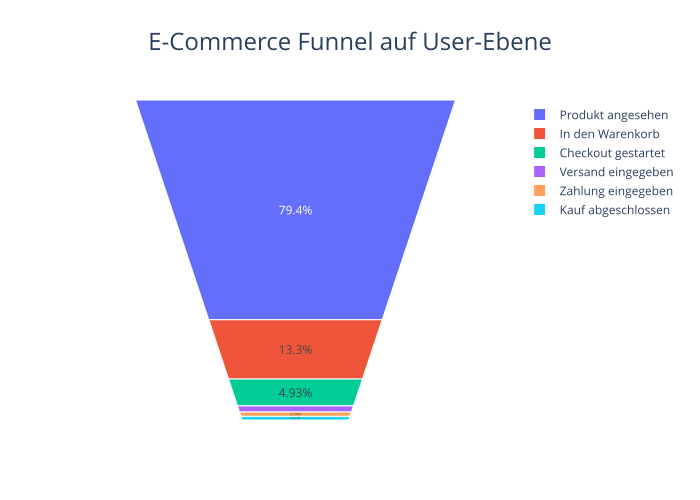

In [29]:
import plotly.express as px

label_map = {
    'view_item':         'Produkt angesehen',
    'add_to_cart':       'In den Warenkorb',
    'begin_checkout':    'Checkout gestartet',
    'add_shipping_info': 'Versand eingegeben',
    'add_payment_info':  'Zahlung eingegeben',
    'purchase':          'Kauf abgeschlossen',
}

df_funnel_plot = df_user_funnel.copy()
df_funnel_plot['step'] = df_funnel_plot['step'].map(label_map)

fig = px.funnel_area(
    df_funnel_plot,
    values='users',
    names='step',
    title='E-Commerce Funnel auf User-Ebene')

fig.update_layout(title_x=0.5, title_font_size=24)

fig.write_image("../figures/funnel_users_overview.png", scale=2)
fig.show(renderer='svg')

In [42]:
df_user_funnel['users_rel'] = df_user_funnel['users'] / df_user_funnel['users'].iloc[0] * 100

df_user_funnel['label'] = df_user_funnel['users_rel'].round(2).astype(str) + "%"

fig = px.funnel(df_user_funnel, y=df_user_funnel['step'].map(label_map), x='users_rel', title='E-Commerce Funnel auf User-Ebene')


fig.update_traces(
    text=df_user_funnel['users_rel'].map(lambda x: f"{x:.2f}%"),
    textinfo="text"  # 🔥 verhindert doppelte Anzeige
    
)

fig.update_layout(
    xaxis_title='Anteil der Nutzer in %',
    yaxis_title='Funnel-Schritte',
    title_x=0.5,    
)

fig.show()


## Funnel Analyse auf Session-Ebene

Im gegensatz zu der Funnel Analyse auf User-Ebene, wird bei dieser Funnel Analyse speziell auf den Zeitraum einer Session geschaut.

Damit zeigt diese Analyse, wie gut ein Nutzer innerhalb einer Session konvertiert.

In [48]:
df_session_funnel_raw = bpd.read_gbq(f"""
WITH events_with_session AS (
  SELECT
    user_pseudo_id,
    (
      SELECT ep.value.int_value
      FROM UNNEST(event_params) AS ep
      WHERE ep.key = 'ga_session_id'
    ) AS ga_session_id,
    event_name,
    event_timestamp
  FROM `bigquery-public-data.ga4_obfuscated_sample_ecommerce.events_*`
  WHERE _TABLE_SUFFIX BETWEEN '{DATE_START}' AND '{DATE_END}'
    AND event_name IN (
      'view_item',
      'add_to_cart',
      'begin_checkout',
      'add_shipping_info',
      'add_payment_info',
      'purchase'
    )
),

session_steps AS (
  SELECT
    user_pseudo_id,
    ga_session_id,
    MIN(IF(event_name = 'view_item',         event_timestamp, NULL)) AS ts_view_item,
    MIN(IF(event_name = 'add_to_cart',       event_timestamp, NULL)) AS ts_add_to_cart,
    MIN(IF(event_name = 'begin_checkout',    event_timestamp, NULL)) AS ts_begin_checkout,
    MIN(IF(event_name = 'add_shipping_info', event_timestamp, NULL)) AS ts_add_shipping_info,
    MIN(IF(event_name = 'add_payment_info',  event_timestamp, NULL)) AS ts_add_payment_info,
    MIN(IF(event_name = 'purchase',          event_timestamp, NULL)) AS ts_purchase
  FROM events_with_session
  WHERE ga_session_id IS NOT NULL
  GROUP BY user_pseudo_id, ga_session_id
)

SELECT
  COUNTIF(ts_view_item IS NOT NULL) AS view_item,
  COUNTIF(
    ts_view_item IS NOT NULL
    AND ts_add_to_cart > ts_view_item
  ) AS add_to_cart,
  COUNTIF(
    ts_view_item IS NOT NULL
    AND ts_add_to_cart > ts_view_item
    AND ts_begin_checkout > ts_add_to_cart
  ) AS begin_checkout,
  COUNTIF(
    ts_view_item IS NOT NULL
    AND ts_add_to_cart > ts_view_item
    AND ts_begin_checkout > ts_add_to_cart
    AND ts_add_shipping_info >= ts_begin_checkout
  ) AS add_shipping_info,
  COUNTIF(
    ts_view_item IS NOT NULL
    AND ts_add_to_cart > ts_view_item
    AND ts_begin_checkout > ts_add_to_cart
    AND ts_add_shipping_info >= ts_begin_checkout
    AND ts_add_payment_info > ts_add_shipping_info
  ) AS add_payment_info,
  COUNTIF(
    ts_view_item IS NOT NULL
    AND ts_add_to_cart > ts_view_item
    AND ts_begin_checkout > ts_add_to_cart
    AND ts_add_shipping_info >= ts_begin_checkout
    AND ts_add_payment_info > ts_add_shipping_info
    AND ts_purchase > ts_add_payment_info
  ) AS purchase
FROM session_steps
""")

df_session_funnel = df_session_funnel_raw.to_pandas().melt(
    var_name='step',
    value_name='sessions'
)

df_session_funnel

,step,sessions
0,view_item,23105
1,add_to_cart,3805
2,begin_checkout,1265
3,add_shipping_info,268
4,add_payment_info,188
5,purchase,135


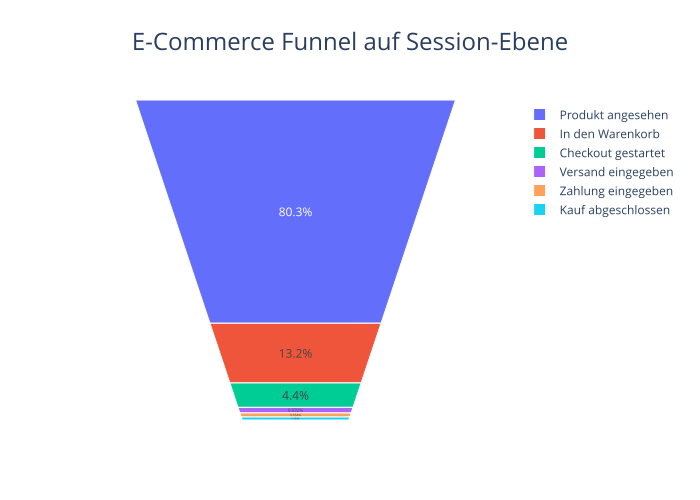

In [51]:
import plotly.express as px

df_funnel_plot = df_session_funnel.copy()
df_funnel_plot['step'] = df_funnel_plot['step'].map(label_map)

fig = px.funnel_area(
    df_funnel_plot,
    values='sessions',
    names='step',
    title='E-Commerce Funnel auf Session-Ebene')

fig.update_layout(title_x=0.5, title_font_size=24)

fig.write_image("../figures/funnel_sessions_overview.png", scale=2)
fig.show(renderer='svg')

In [49]:
df_session_funnel['sessions_rel'] = df_session_funnel['sessions'] / df_session_funnel['sessions'].iloc[0] * 100

df_session_funnel['label'] = df_session_funnel['sessions_rel'].round(2).astype(str) + "%"

fig = px.funnel(df_session_funnel, y=df_session_funnel['step'].map(label_map), x='sessions_rel', title='E-Commerce Funnel auf Session-Ebene')
fig.update_traces(
    text=df_session_funnel['sessions_rel'].map(lambda x: f"{x:.2f}%"),
    textinfo="text" 
    
)

fig.update_layout(
    xaxis_title='Anteil der Nutzer in %',
    yaxis_title='Funnel-Schritte',
    title_x=0.5,    
)

fig.show()


## 6. Drop-off Analyse

Um die Problembereiche zu erkennen, wird jetzt eine Drop-Off Analyse durchgeführt.

- **`pct_of_start`** beschreibt wie viel % der initialen Session-User noch dabei sind
- **`step_conversion_pct`** beschreibt wie viel % der User des *vorherigen* Schritts weitergehen

Ein niedriger `step_conversion_pct` zeigt, wo der größte Handlungsbedarf besteht.

In [53]:
df_dropoff = df_user_funnel.copy()

df_dropoff['pct_of_start']      = (df_dropoff['users'] / df_dropoff['users'].iloc[0] * 100).round(2)
df_dropoff['step_conversion_pct'] = (df_dropoff['users'] / df_dropoff['users'].shift(1) * 100).round(2)
df_dropoff['dropoff_users']     = df_dropoff['users'].shift(1) - df_dropoff['users']

df_dropoff

,step,users,users_rel,label,pct_of_start,step_conversion_pct,dropoff_users
0,view_item,19629,100.0,100.0%,100.0,<NA>,<NA>
1,add_to_cart,3295,16.786387,16.79%,16.79,16.79,16334
2,begin_checkout,1217,6.20001,6.2%,6.2,36.93,2078
3,add_shipping_info,252,1.283815,1.28%,1.28,20.71,965
4,add_payment_info,174,0.886444,0.89%,0.89,69.05,78
5,purchase,141,0.718325,0.72%,0.72,81.03,33


In [55]:
import plotly.graph_objects as go

df_plot = df_dropoff.copy()
df_plot['label'] = df_plot['step'].map(label_map)

def conv_color(pct):
    if pct is None or str(pct) == '<NA>':
        return '#4a90d9'
    pct = float(pct)
    if pct < 50:   return '#e74c3c'
    if pct < 75:   return '#f39c12'
    return '#27ae60'

bar_colors = [conv_color(v) for v in df_plot['step_conversion_pct']]

fig1 = go.Figure()

fig1.add_trace(go.Bar(
    y=df_plot['label'][::-1],
    x=df_plot['users'][::-1],
    orientation='h',
    marker_color=bar_colors[::-1],
    text=[f"{u:,}" for u in df_plot['users'][::-1]],
    textposition='inside',
    insidetextanchor='middle',
    textfont=dict(color='white', size=12),
    name='User',
    showlegend=False,
))

for _, row in df_plot.iterrows():
    if str(row['dropoff_users']) in ('<NA>', 'nan'):
        continue
    drop = int(row['dropoff_users'])
    conv = float(row['step_conversion_pct'])
    if drop == 0:
         color, text =  "#D48505", "= Kein User verloren"
    else:
        color = "", "#e74c3c"
        text = f"{drop:,} ({100 - conv:.0f}% weg)"
    fig1.add_annotation(
        y=row['label'], x=row['users'] + 300,
        text=text, showarrow=False,
        font=dict(color=color, size=11), xanchor='left',
    )

fig1.update_layout(
    title=dict(text='Funnel: User pro Ebene + Drop-offs', x=0.5, font=dict(size=18)),
    height=450, plot_bgcolor='white', paper_bgcolor='white',
    xaxis=dict(showgrid=True, gridcolor='#eeeeee'),
    margin=dict(l=20, r=20, t=60, b=40),
)

fig1.write_image("../figures/funnel_users.png", scale=2)
fig1.show(renderer='svg')

df_conv = df_plot[df_plot['step_conversion_pct'].notna() & (df_plot['step_conversion_pct'].astype(str) != '<NA>')].copy()
df_conv['step_conversion_pct'] = df_conv['step_conversion_pct'].astype(float)
conv_colors = [conv_color(v) for v in df_conv['step_conversion_pct']]

fig2 = go.Figure()

fig2.add_trace(go.Bar(
    y=df_conv['label'][::-1],
    x=df_conv['step_conversion_pct'][::-1],
    orientation='h',
    marker_color=conv_colors[::-1],
    text=[f"{v:.1f}%" for v in df_conv['step_conversion_pct'][::-1]],
    textposition='outside',
    textfont=dict(size=11),
    name='Conversion',
    showlegend=False,
))

fig2.add_vline(x=50, line_dash='dot', line_color='#e74c3c', opacity=0.5)
fig2.add_vline(x=75, line_dash='dot', line_color='#f39c12', opacity=0.5)


for x_pos, color, label in [
    (0.2, '#e74c3c', '< 50%'),
    (0.5, '#f39c12', '< 75%'),
    (0.8, '#27ae60', '>= 75%'),
]:
    fig2.add_annotation(
        x=x_pos, y=-0.15, xref='paper', yref='paper',
        text=label, showarrow=False,
        font=dict(size=12, color=color), xanchor='center',
    )

fig2.update_layout(
    title=dict(text='Step-Conversion Rate (%)', x=0.5, font=dict(size=18)),
    height=450, plot_bgcolor='white', paper_bgcolor='white',
    xaxis=dict(range=[0, 110], showgrid=True, gridcolor='#eeeeee'),
    margin=dict(l=20, r=20, t=60, b=60),
)

fig2.write_image("../figures/funnel_conversion.png", scale=2)
fig2.show(renderer='svg')

ValueError: 
    Invalid value of type 'builtins.tuple' received for the 'color' property of layout.annotation.font
        Received value: ('', '#e74c3c')

    The 'color' property is a color and may be specified as:
      - A hex string (e.g. '#ff0000')
      - An rgb/rgba string (e.g. 'rgb(255,0,0)')
      - An hsl/hsla string (e.g. 'hsl(0,100%,50%)')
      - An hsv/hsva string (e.g. 'hsv(0,100%,100%)')
      - A named CSS color: see https://plotly.com/python/css-colors/ for a list

## 7. Segmentierung 

Gibt es unterschied bei der Kaufconversion bei den unterschiedliche Geräten? (Tablet, Desktop, Mobile)

In [58]:
df_device = bpd.read_gbq(f"""
SELECT
  device.category                                                                AS device_category,
  COUNT(DISTINCT user_pseudo_id)                                                 AS users,
  COUNT(DISTINCT IF(event_name = 'purchase', user_pseudo_id, NULL))              AS purchases,
  ROUND(COUNT(DISTINCT IF(event_name = 'purchase', user_pseudo_id, NULL)) 
        * 100.0 / NULLIF(COUNT(DISTINCT user_pseudo_id), 0), 2)                 AS conversion_rate_pct
FROM `bigquery-public-data.ga4_obfuscated_sample_ecommerce.events_*`
CROSS JOIN UNNEST(event_params) AS p
WHERE _TABLE_SUFFIX BETWEEN '{DATE_START}' AND '{DATE_END}'
GROUP BY device.category
""")
df_device = df_device.sort_values(by='conversion_rate_pct', ascending=False)
df_device.to_pandas()

,device_category,users,purchases,conversion_rate_pct
0,tablet,2166,29,1.34
2,mobile,37934,450,1.19
1,desktop,55236,594,1.08


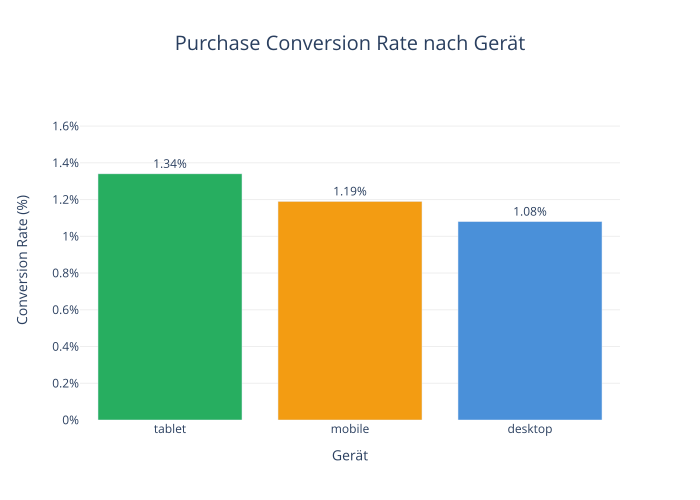

In [60]:
df_dev_pd = df_device.to_pandas().sort_values('conversion_rate_pct', ascending=False)

fig = px.bar(
    df_dev_pd,
    x='device_category',
    y='conversion_rate_pct',
    text=df_dev_pd['conversion_rate_pct'].apply(lambda x: f'{x:.2f}%'),
    color='device_category',
    color_discrete_map={'desktop': '#4a90d9', 'mobile': '#f39c12', 'tablet': '#27ae60'},
    labels={'device_category': 'Gerät', 'conversion_rate_pct': 'Conversion Rate (%)'},
    title='Purchase Conversion Rate nach Gerät',
)

fig.update_traces(textposition='outside')
fig.update_layout(
    title_x=0.5,
    title_font_size=20,
    showlegend=False,
    yaxis=dict(ticksuffix='%', range=[0, df_dev_pd['conversion_rate_pct'].max() * 1.3]),
    plot_bgcolor='white',
    paper_bgcolor='white',
    xaxis=dict(showgrid=False),
    yaxis_showgrid=True,
    yaxis_gridcolor='#eeeeee',
)

fig.write_image('../figures/device_conversion_rate.png', scale=2, width=600, height=400)
fig.show(renderer='svg')

Welche 10 Länder haben die größte prozentuale Kaufconversion?

In [59]:
df_country = bpd.read_gbq(f"""
SELECT
  geo.country                                                                    AS country,
  COUNT(DISTINCT user_pseudo_id)                                                 AS users,
  COUNT(DISTINCT IF(event_name = 'purchase', user_pseudo_id, NULL))              AS purchases,
  ROUND(COUNT(DISTINCT IF(event_name = 'purchase', user_pseudo_id, NULL))
        * 100.0 / NULLIF(COUNT(DISTINCT user_pseudo_id), 0), 2)                 AS conversion_rate_pct
FROM `bigquery-public-data.ga4_obfuscated_sample_ecommerce.events_*`
WHERE _TABLE_SUFFIX BETWEEN '{DATE_START}' AND '{DATE_END}'
  AND geo.country IS NOT NULL
  AND geo.country != ''
GROUP BY geo.country
HAVING COUNT(DISTINCT user_pseudo_id) >= 500
ORDER BY conversion_rate_pct DESC 
LIMIT 10
""")

df_country = df_country.to_pandas().sort_values('conversion_rate_pct', ascending=False)
df_country

,country,users,purchases,conversion_rate_pct
9,Netherlands,1078,20,1.86
4,Hong Kong,587,10,1.7
2,Poland,832,14,1.68
7,Japan,1270,21,1.65
8,Philippines,502,8,1.59
0,Australia,872,13,1.49
5,Taiwan,1623,24,1.48
6,Canada,7043,92,1.31
1,Spain,1781,23,1.29
3,Brazil,949,12,1.26


## 8. Revenue-Analyse — Was bringt der Funnel monetär?

Die Kaufconversion selber sagt noch nicht allzu viel aus, aufgrund der unterschiedlichen Umsätze der Kunden, deshalb wird darauf jetzt geschaut

In [63]:
df_revenue = bpd.read_gbq(f"""
WITH purchase_events AS (
  SELECT
    CONCAT(user_pseudo_id, '-', CAST(event_timestamp AS STRING)) AS purchase_id,
    user_pseudo_id,

    COALESCE(
      (SELECT ep.value.double_value
       FROM UNNEST(event_params) ep
       WHERE ep.key = 'value'),
      CAST((
        SELECT ep.value.int_value
        FROM UNNEST(event_params) ep
        WHERE ep.key = 'value'
      ) AS FLOAT64)
    ) AS value,

    items
  FROM `bigquery-public-data.ga4_obfuscated_sample_ecommerce.events_*`
  WHERE event_name = 'purchase'
    AND _TABLE_SUFFIX BETWEEN '{DATE_START}' AND '{DATE_END}'
),

purchase_revenue AS (
  SELECT
    purchase_id,
    user_pseudo_id,
    value,

    SUM(item.price * item.quantity) AS item_revenue

  FROM purchase_events,
  UNNEST(items) AS item

  GROUP BY purchase_id, user_pseudo_id, value
),

final_revenue AS (
  SELECT
    purchase_id,
    user_pseudo_id,

    -- FINAL Revenue Definition
    COALESCE(value, item_revenue) AS revenue

  FROM purchase_revenue
)

SELECT
  COUNT(DISTINCT user_pseudo_id) AS buying_users,
  COUNT(*) AS total_purchases,

  ROUND(SUM(revenue), 2) AS total_revenue,
  ROUND(AVG(revenue), 2) AS avg_order_value

FROM final_revenue
WHERE revenue IS NOT NULL
""")

df_revenue.to_pandas()


,buying_users,total_purchases,total_revenue,avg_order_value
0,819,904,57360.51,63.45


In [61]:
df_daily = bpd.read_gbq(f"""
SELECT
  event_date,
  COUNT(DISTINCT user_pseudo_id)      AS buying_users,
  ROUND(SUM(p.value.double_value), 2) AS daily_revenue,
  ROUND(AVG(p.value.double_value), 2) AS avg_order_value
FROM `bigquery-public-data.ga4_obfuscated_sample_ecommerce.events_*`
CROSS JOIN UNNEST(event_params) AS p
WHERE _TABLE_SUFFIX BETWEEN '{DATE_START}' AND '{DATE_END}'
  AND event_name = 'purchase'
  AND p.key = 'value'
GROUP BY event_date
""")

df_daily = df_daily.to_pandas().sort_values('event_date').reset_index(drop=True)
df_daily

,event_date,buying_users,daily_revenue,avg_order_value
0,20210101,12,810.65,81.06
1,20210102,13,936.01,104.0
2,20210103,13,413.28,59.04
3,20210104,16,678.04,52.16
4,20210105,26,827.3,48.66
...,...,...,...,...
25,20210126,21,838.5,59.89
26,20210127,12,241.6,30.2
27,20210128,5,115.47,28.87
28,20210129,6,109.92,27.48


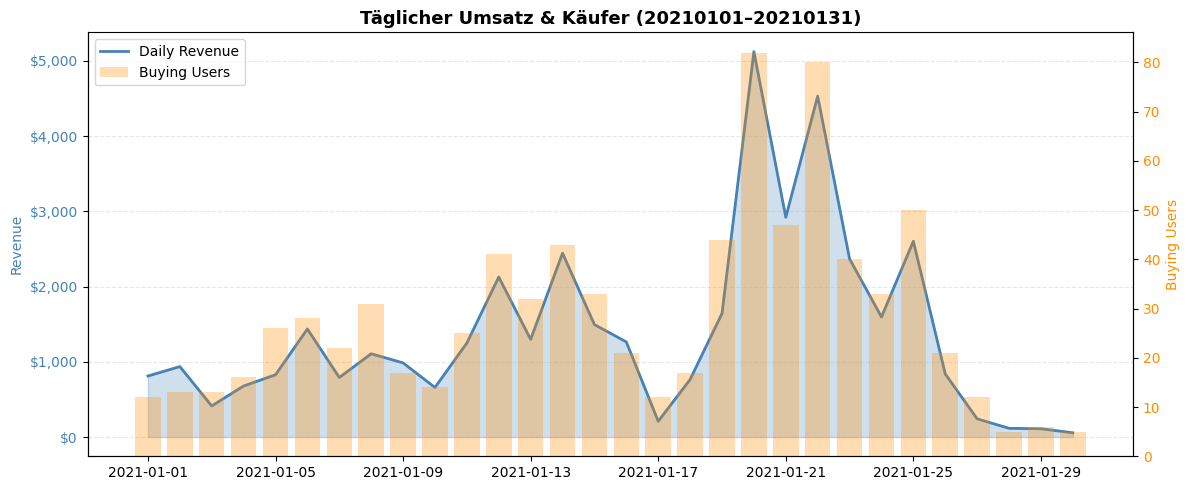

In [62]:
df_daily_pd = df_daily.copy()
df_daily_pd['event_date'] = pd.to_datetime(df_daily_pd['event_date'], format='%Y%m%d')

fig, ax1 = plt.subplots(figsize=(12, 5))

ax1.fill_between(df_daily_pd['event_date'], df_daily_pd['daily_revenue'],
                 alpha=0.25, color='steelblue')
ax1.plot(df_daily_pd['event_date'], df_daily_pd['daily_revenue'],
         color='steelblue', linewidth=2, label='Daily Revenue')
ax1.set_ylabel('Revenue', color='steelblue')
ax1.tick_params(axis='y', labelcolor='steelblue')
ax1.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'${x:,.0f}'))

ax2 = ax1.twinx()
ax2.bar(df_daily_pd['event_date'], df_daily_pd['buying_users'],
        alpha=0.3, color='darkorange', width=pd.Timedelta(days=0.8), label='Buying Users')
ax2.set_ylabel('Buying Users', color='darkorange')
ax2.tick_params(axis='y', labelcolor='darkorange')

ax1.set_title(f'Täglicher Umsatz & Käufer ({DATE_START}–{DATE_END})',
              fontsize=13, fontweight='bold')
ax1.spines[['top']].set_visible(False)
ax1.grid(axis='y', linestyle='--', alpha=0.3)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.tight_layout()
plt.savefig('../figures/daily_revenue_chart.png', dpi=150, bbox_inches='tight')
plt.show()


In [64]:
df_products = bpd.read_gbq(f"""
WITH product_events AS (
  SELECT
    item.item_name                          AS product_name,
    item.item_category                      AS category,
    ROUND(AVG(item.price), 2)               AS avg_price,
 
    COUNTIF(event_name = 'view_item')       AS views,
    COUNTIF(event_name = 'add_to_cart')     AS add_to_cart,
    COUNTIF(event_name = 'purchase')        AS purchases,
 
    SUM(IF(event_name = 'purchase',
           item.quantity * item.price, 0))  AS total_revenue
 
  FROM `bigquery-public-data.ga4_obfuscated_sample_ecommerce.events_*`,
  UNNEST(items) AS item
 
  WHERE _TABLE_SUFFIX BETWEEN '{DATE_START}' AND '{DATE_END}'
    AND event_name IN ('view_item', 'add_to_cart', 'purchase')
    AND item.item_name IS NOT NULL
 
  GROUP BY product_name, category
),
 
rates AS (
  SELECT
    *,
    ROUND(SAFE_DIVIDE(add_to_cart, views) * 100, 2)  AS view_to_cart_rate,
    ROUND(SAFE_DIVIDE(purchases,   views) * 100, 2)  AS view_to_purchase_rate,
    ROUND(SAFE_DIVIDE(purchases, add_to_cart) * 100, 2) AS cart_to_purchase_rate
  FROM product_events
  WHERE views >= 50  -- Nur Produkte mit ausreichend Datenbasis
)
 
SELECT *
FROM rates
ORDER BY views DESC
""")
 
df_products_pd = df_products.to_pandas()
df_products_pd

,product_name,category,avg_price,views,add_to_cart,purchases,total_revenue,view_to_cart_rate,view_to_purchase_rate,cart_to_purchase_rate
0,Super G Unisex Joggers,Home/Apparel/,37.0,3035,671,0,0.0,22.11,0.0,0.0
1,Google Infant Charcoal Onesie,Home/Apparel/Kids/,25.0,315,117,0,0.0,37.14,0.0,0.0
2,Android Jotter Task Pad,Home/Eco-Friendly/,3.0,1463,310,0,0.0,21.19,0.0,0.0
3,Google Hemp Tote,Home/Eco-Friendly/,22.0,511,125,0,0.0,24.46,0.0,0.0
4,Google Land & Sea Unisex Tee,Home/Apparel/Women's/,25.0,62,16,0,0.0,25.81,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...
836,Stainless Straight Straw/Cleaner,Lifestyle/Drinkware/,4.0,1447,311,0,0.0,21.49,0.0,0.0
837,Google Camp Mug Ivory,Home/Shop by Brand/,13.0,100,31,0,0.0,31.0,0.0,0.0
838,Google Magnet,Lifestyle/,8.0,726,113,0,0.0,15.56,0.0,0.0
839,Google Blue Stojo Cup,Home/New/,25.0,2944,519,0,0.0,17.63,0.0,0.0


In [65]:
top10_views = df_products_pd.nlargest(10, 'views').sort_values('views')
 
fig_views = px.bar(
    top10_views,
    x='views',
    y='product_name',
    orientation='h',
    text='views',
    color='view_to_cart_rate',
    color_continuous_scale='RdYlGn',
    color_continuous_midpoint=df_products_pd['view_to_cart_rate'].median(),
    labels={
        'views':              'Produktansichten',
        'product_name':       'Produkt',
        'view_to_cart_rate':  'View-to-Cart-Rate (%)'
    },
    title='Top-10 Produkte nach Views — Farbe zeigt View-to-Cart-Rate',
)
fig_views.update_traces(textposition='outside')
fig_views.update_layout(
    height=480,
    coloraxis_colorbar=dict(title='View-to-Cart<br>Rate (%)'),
    xaxis_title='Produktansichten',
    yaxis_title=None,
)
fig_views.show()

In [66]:
view_threshold      = df_products_pd['views'].quantile(0.75)
cart_rate_threshold = df_products_pd['view_to_cart_rate'].quantile(0.25)
 
problem_products = (
    df_products_pd[
        (df_products_pd['views'] >= view_threshold) &
        (df_products_pd['view_to_cart_rate'] <= cart_rate_threshold)
    ]
    .sort_values('views', ascending=False)
    .head(10)
)
 
print(f"Produkte mit hohen Views (≥{view_threshold:.0f}) aber niedriger Cart-Rate (≤{cart_rate_threshold:.1f}%):")
problem_products[['product_name', 'views', 'add_to_cart', 'view_to_cart_rate', 'avg_price']]

Produkte mit hohen Views (≥882) aber niedriger Cart-Rate (≤18.8%):


,product_name,views,add_to_cart,view_to_cart_rate,avg_price
640,Google Utility BackPack,3071,370,12.05,120.0
408,Google Flat Front Bag Grey,3020,389,12.88,30.0
839,Google Blue Stojo Cup,2944,519,17.63,25.0
150,Google Land & Sea Tech Taco,2932,526,17.94,4.0
786,Google Land & Sea French Terry Sweatshirt,2909,525,18.05,55.0
569,Google Mesh Bag Blue,2839,380,13.38,6.0
742,Google Incognito Messenger Bag,2821,352,12.48,75.0
194,Google Utility Bag Grey,2811,361,12.84,10.0
85,Google Campus Bike Tote Navy,2810,371,13.2,11.0
668,Google Confetti Accessory Pouch,2785,362,13.0,12.0


In [67]:
median_views     = df_products_pd['views'].median()
median_cart_rate = df_products_pd['view_to_cart_rate'].median()
 
fig_scatter = px.scatter(
    df_products_pd,
    x='views',
    y='view_to_cart_rate',
    size='total_revenue',
    color='cart_to_purchase_rate',
    hover_name='product_name',
    hover_data={
        'avg_price':             True,
        'purchases':             True,
        'views':                 True,
        'view_to_cart_rate':     True,
        'cart_to_purchase_rate': True,
        'total_revenue':         True,
    },
    color_continuous_scale='Blues',
    labels={
        'views':                 'Produktansichten',
        'view_to_cart_rate':     'View-to-Cart-Rate (%)',
        'cart_to_purchase_rate': 'Cart-to-Purchase-Rate (%)',
        'total_revenue':         'Gesamtumsatz (€)',
    },
    title='Produkt-Matrix: Sichtbarkeit vs. Kaufbereitschaft',
)
 
# Quadranten-Linien
fig_scatter.add_vline(x=median_views,     line_dash='dash', line_color='gray', opacity=0.5)
fig_scatter.add_hline(y=median_cart_rate, line_dash='dash', line_color='gray', opacity=0.5)
 
# Quadranten-Labels
annotations = [
    dict(x=0.02, y=0.98, xref='paper', yref='paper', showarrow=False,
         text='⚡ Nische, aber effizient',   font=dict(size=11, color='gray'), xanchor='left', yanchor='top'),
    dict(x=0.98, y=0.98, xref='paper', yref='paper', showarrow=False,
         text='★ Star-Produkte',             font=dict(size=11, color='green'), xanchor='right', yanchor='top'),
    dict(x=0.98, y=0.02, xref='paper', yref='paper', showarrow=False,
         text='⚠ Optimierungsbedarf',        font=dict(size=11, color='red'), xanchor='right', yanchor='bottom'),
    dict(x=0.02, y=0.02, xref='paper', yref='paper', showarrow=False,
         text='◎ Kaum relevant',             font=dict(size=11, color='gray'), xanchor='left', yanchor='bottom'),
]
fig_scatter.update_layout(
    annotations=annotations,
    height=520,
    coloraxis_colorbar=dict(title='Cart-to-Purchase<br>Rate (%)'),
)
fig_scatter.show()

In [69]:
from plotly.subplots import make_subplots

top10_revenue = (
    df_products_pd[df_products_pd['total_revenue'] > 0]
    .nlargest(10, 'total_revenue')
    .sort_values('total_revenue')
)
 
fig_revenue = make_subplots(specs=[[{"secondary_y": True}]])
 
fig_revenue.add_trace(
    go.Bar(
        y=top10_revenue['product_name'],
        x=top10_revenue['total_revenue'],
        orientation='h',
        name='Gesamtumsatz (€)',
        marker_color='#4a90d9',
        text=top10_revenue['total_revenue'].apply(lambda x: f'€{x:,.0f}'),
        textposition='outside',
    ),
    secondary_y=False,
)
 
fig_revenue.add_trace(
    go.Scatter(
        y=top10_revenue['product_name'],
        x=top10_revenue['avg_price'],
        mode='markers',
        name='Ø Preis (€)',
        marker=dict(color='#e74c3c', size=10, symbol='diamond'),
    ),
    secondary_y=True,
)
 
fig_revenue.update_layout(
    title='Top-10 Produkte nach Umsatz — mit Ø Preis',
    height=480,
    xaxis_title='Gesamtumsatz (€)',
    legend=dict(orientation='h', yanchor='bottom', y=1.02, xanchor='right', x=1),
)
fig_revenue.update_yaxes(title_text='Ø Preis (€)', secondary_y=True)
fig_revenue.show()
 

## Zusammenfassung

Key Findings


Business Impact


Empfehlungen
